In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
path= '/content/drive/MyDrive/thesis/code'
os.chdir(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import re

In [3]:
def highlight_words(text, ranges):
    words = text.split()
    highlighted_text = []
    for i, word in enumerate(words):
        if any(start <= i < end for start, end in ranges):
            highlighted_text.append(f"\033[42m{word}\033[0m")  # yellow background
        else:
            highlighted_text.append(word)
    text = " ".join(highlighted_text)
    for i in range(0, len(text), 500):
        print(text[i:i+500])

In [56]:
def print_experiment_instance(path, task, model, idx):

    os.chdir(path+f'/attacks/{task}_attacks')
    attack = pd.read_csv(f"{model}_TextFoolerJin2019.csv")

    introspections_path = path + f'/introspections/{task}_introspections/{model}/results/analysis'
    sqlite_files = [f for f in os.listdir(introspections_path) if f.endswith('.sqlite')]
    conn = sqlite3.connect(os.path.join(introspections_path, sqlite_files[0]))
    df = pd.read_sql_query("SELECT * FROM Counterfactual", conn)

    print('\n' + '='*80)
    print(f'\033[1;34mEXPERIMENT: Introspection on {'IMDB' if task == 'movies' else 'e-Snli'}\033[0m')
    print('='*80)
    print(f'\n\033[1;34mPrinting instance with index {idx}\033[0m')

    print('\n\033[1m1. CLASSIFICATION\033[0m')
    print(f'→ Prompt: {df.iloc[idx]["predict_prompt"].replace('Paragraph','\n\t  Paragraph')}')

    classification = df.iloc[idx]["predict"].strip().lower()
    color = "\033[1;32m" if (classification == "positive" or classification == "yes") else "\033[1;31m"
    print(f'→ Classification: {color}{classification.upper()}\033[0m')

    print('\n\033[1m2. ADVERSARIAL ATTACK (TextFoolerJin)\033[0m')
    if task == 'esnli':
        text = attack.iloc[idx]['perturbed_text'].split('.')[1]
        print('→ Perturbed Text:',re.sub(r"\[\[(.*?)\]\]", "\033[1;38;5;208m\\1\033[0m", text))
    else:
        text = attack.iloc[idx]['perturbed_text']
        print('→ Perturbed Text:',re.sub(r"\[\[(.*?)\]\]", "\033[1;38;5;208m\\1\033[0m", text))
    print('Result:', attack.iloc[idx]['original_output'], '→' ,attack.iloc[idx]['perturbed_output'],'Status:', attack.iloc[idx]['result_type'])

    print('\n\033[1m3. COUNTERFACTUAL GENERATION\033[0m')
    for file in sqlite_files:
        conn = sqlite3.connect(os.path.join(introspections_path, file))
        df = pd.read_sql_query("SELECT * FROM Counterfactual", conn)
        variant = file.split('_c-')[1].split('_s')[0] if file.split('_c-')[1].split('_s')[0] else 'default'
        print(f'• Variant: \033[1;36m{variant}\033[0m')
        print(f'  Prompt: {df.iloc[idx]["explain_prompt"]}')
        print(f'  CF Edit: {df.iloc[idx]["explain"]}')
        classification = df.iloc[idx]["explain_predict"].strip().lower()
        color = "\033[1;32m" if (classification == "positive" or classification == "yes") else "\033[1;31m"
        print(f'  CF Classification: {color}{classification.upper()}\033[0m | Faithfulness: {int(df.iloc[idx]["faithful"])}')
        print('-'*60)


In [5]:
os.chdir(path + '/eraserbenchmark-master')
from rationale_benchmark.utils import load_documents, load_datasets, annotations_from_jsonl, Annotation

#**Datasets**

##**IMDB**

In [6]:
movies_data_root = path + '/eraserbenchmark-master/data/movies'
movies_documents = load_documents(movies_data_root)
movies = annotations_from_jsonl(os.path.join(movies_data_root, 'test.jsonl'))

In [7]:
instance = movies[0]
text =  " ".join(word for sentence in movies_documents[instance.annotation_id] for word in sentence)
ranges = []
for ev in next(iter(instance.evidences)):
    ranges.append((ev.start_token, ev.end_token))
highlight_words(text, ranges)

there may not be a critic alive who harbors as much affection for shlock monster movies as i do . i delighted in the sneaky - smart entertainment of ron underwood 's big - underground - worm yarn tremors ; i even giggled at last year 's critically - savaged big - underwater - snake yarn anaconda . something about these films causes me to lower my inhibitions and retu
rn to the saturday afternoons of my youth , spent in the company of ghidrah , the creature from the black lagoon and the blob . deep rising , a big - undersea - serpent yarn , does n't quite pass the test . sure enough , all the modern monster movie ingredients are in place : a conspicuously multi - ethnic / multi - national collection of bait . .. excuse me 
, characters ; an isolated location , here a derelict cruise ship in the south china sea ; some comic relief ; a few cgi - enhanced gross - outs ; and at least one big explosion . there are too - cheesy - to - be - accidental elements , like a sleazy shipping magnate 

##**e-SNLI**

In [8]:
esnli_data_root = path + '/eraserbenchmark-master/data/esnli'
esnli_documents = load_documents(esnli_data_root)
esnli = annotations_from_jsonl(os.path.join(esnli_data_root, 'test.jsonl'))
esnli[:] = [instance for instance in esnli if instance.classification != 'neutral']  #filter out neutral for binary classification

In [9]:
instance = esnli[1]
hypothesis = " ".join(word for sentence in esnli_documents[instance.annotation_id+'_hypothesis'] for word in sentence)
premise = " ".join(word for sentence in esnli_documents[instance.annotation_id+'_premise'] for word in sentence)
premise_evs = []
hypothesis_evs = []
for ev in next(iter(instance.evidences)):
    if ev.docid.split('_')[1] == 'hypothesis':
        hypothesis_evs.append((ev.start_token, ev.end_token))
    else:
        premise_evs.append((ev.start_token, ev.end_token))
print('Hypothesis:')
highlight_words(hypothesis, hypothesis_evs)
print('Premise:')
highlight_words(premise, premise_evs)

Hypothesis:
There is a man wearing cloths.
Premise:
A man in green pants and blue shirt pushing a cart.


#**CLASSIFIERS**

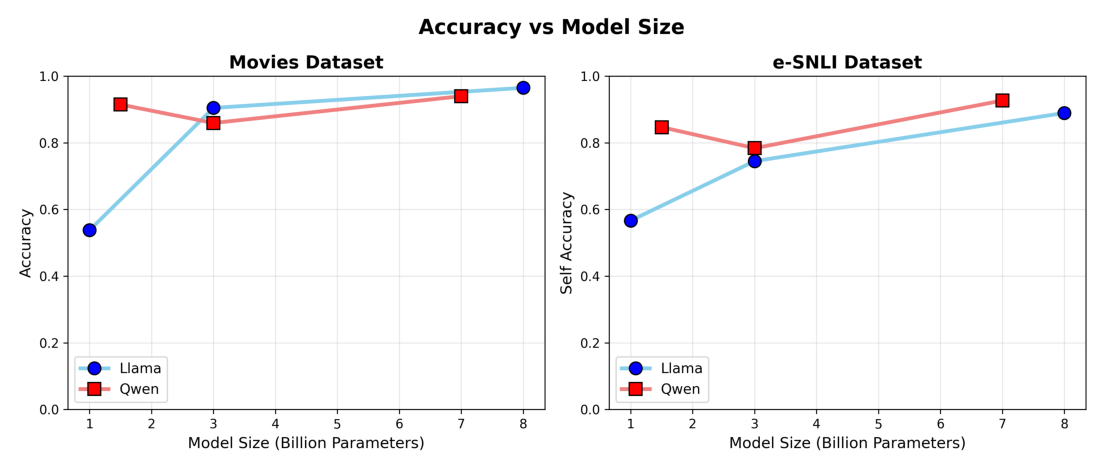

In [10]:
os.chdir(path+'/results')
img = mpimg.imread('classifiers_accuracy_vs_size.png')
plt.figure(figsize=(14, 14))
plt.imshow(img)
plt.axis('off')
plt.show()

#**1. COUNTERFACTUALS GENERATION**

###**Task: IMDB**

**Experiments:**

In [59]:
model = 'Meta-Llama-3-8B-Instruct'
task = 'movies'
idx = random.randint(1, len(movies))
print_experiment_instance(path, task, model, idx)


EXPERIMENT: Introspection on IMDB

Printing instance with index 182

1. CLASSIFICATION
→ Prompt: You are a sentiment classifier. Answer only "positive" or "negative". Do not explain the answer. What is the sentiment of the user's paragraph?
	  Paragraph: few films in 1999 have divided the critical consensus as sharply as alan parker 's adaptation of frank mccourt 's memoir angela 's ashes . many dismissed it as an humorless , sentimentalized , uninteresting version of the hugely popular novel ; others hailed it as a heartfelt , sincere portrait of the human spirit . i 'm somewhere in between , leaning strongly towards the latter . it 's certainly well - made and it never becomes tedious like some literary adaptations have a tendency to be . but i have a feeling that parker filled the movie with pseudo - lyrical shots of rain falling on the homely streets of ireland just so it can have the two - and - a - half hour running time that screams " i 'm important ! " mccourt 's book of the s

**Evaluation:**

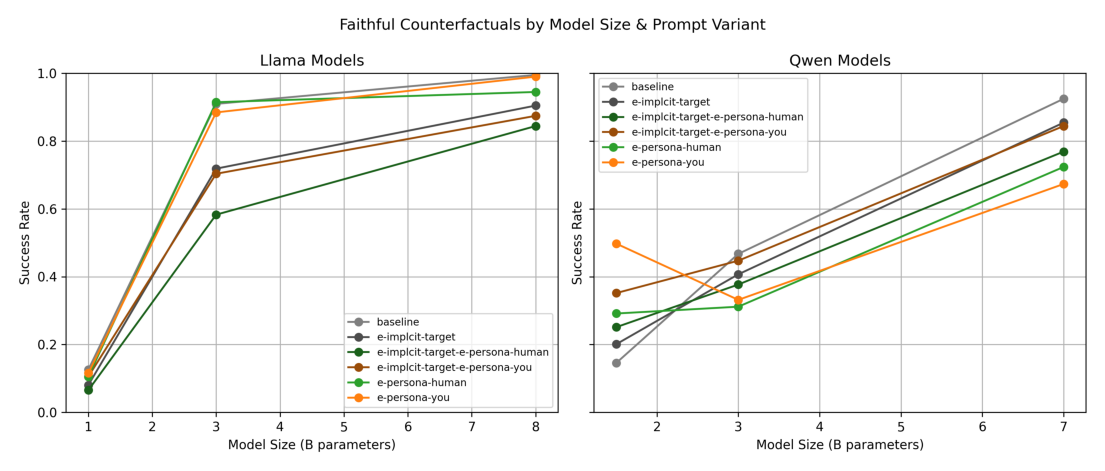

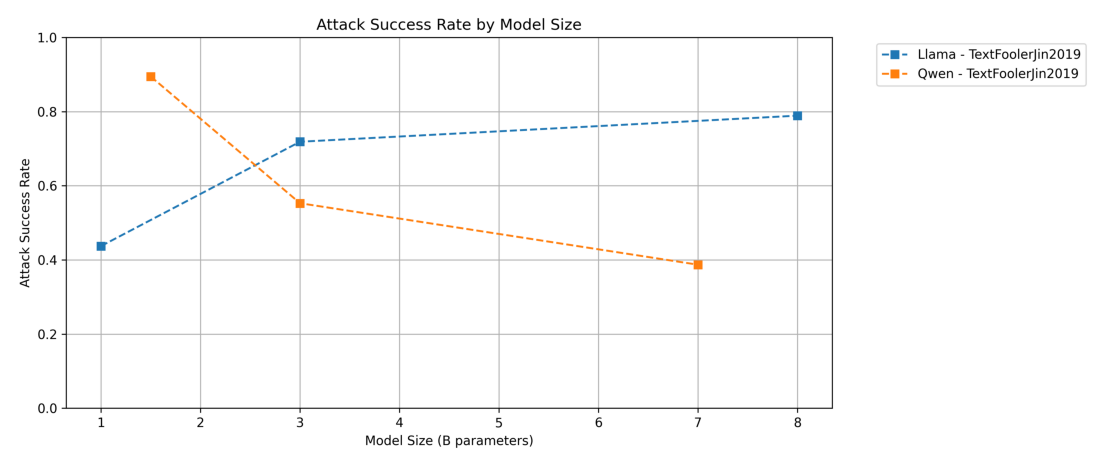

In [12]:
plotsDir = path + '/results/movie_results/plots'
plots = ['Introspection_Success.png', 'Attack_Success.png']

for plot in plots:
    img = mpimg.imread(plotsDir+'/'+plot)
    plt.figure(figsize=(14,10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

###**Task: e-SNLI**

**Experiment:**

In [16]:
model = 'Meta-Llama-3-8B-Instruct'
task = 'esnli'
idx = random.randint(0, len(esnli))
print_experiment_instance(path, task, model, idx)


EXPERIMENT: Introspection on e-Snli

Printing instance with index 245

1. CLASSIFICATION
→ Prompt: Does the statement "a woman holding a scruffy cat" entail from the following paragraph? Answer either "yes" for entailment or "no" for no entailment. Do not explain the answer.
	  Paragraph: An elderly lady holding a scruffy dog and smiling contently.
→ Classification: NO

2. ADVERSARIAL ATTACK (TextFoolerJin)
An elderly lady holding a scruffy bichon and smiling contently
Result: 0 → 1 Status: Successful

3. COUNTERFACTUAL GENERATION
• Variant: default
  Prompt: Edit the following paragraph such that the statement "a woman holding a scruffy cat" entails from it. Make as few edits to the paragraph as possible. Do not explain the answer.
  CF Edit: An elderly lady holding a scruffy cat and smiling contently.
  CF Classification: YES | Faithfulness: 1
------------------------------------------------------------
• Variant: e-implcit-target-e-persona-you
  Prompt: Edit the following paragraph

**Evaluation:**

In [ ]:
plotsDir = path + '/results/esnli_results/plots'
plots = ['Introspection_Success.png', 'Attack_Success.png']

for plot in plots:
    img = mpimg.imread(plotsDir+'/'+plot)
    plt.figure(figsize=(16,12))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

#**2. QUALITY EVALUATION**

###**Task: IMDB**

**Experiment:**

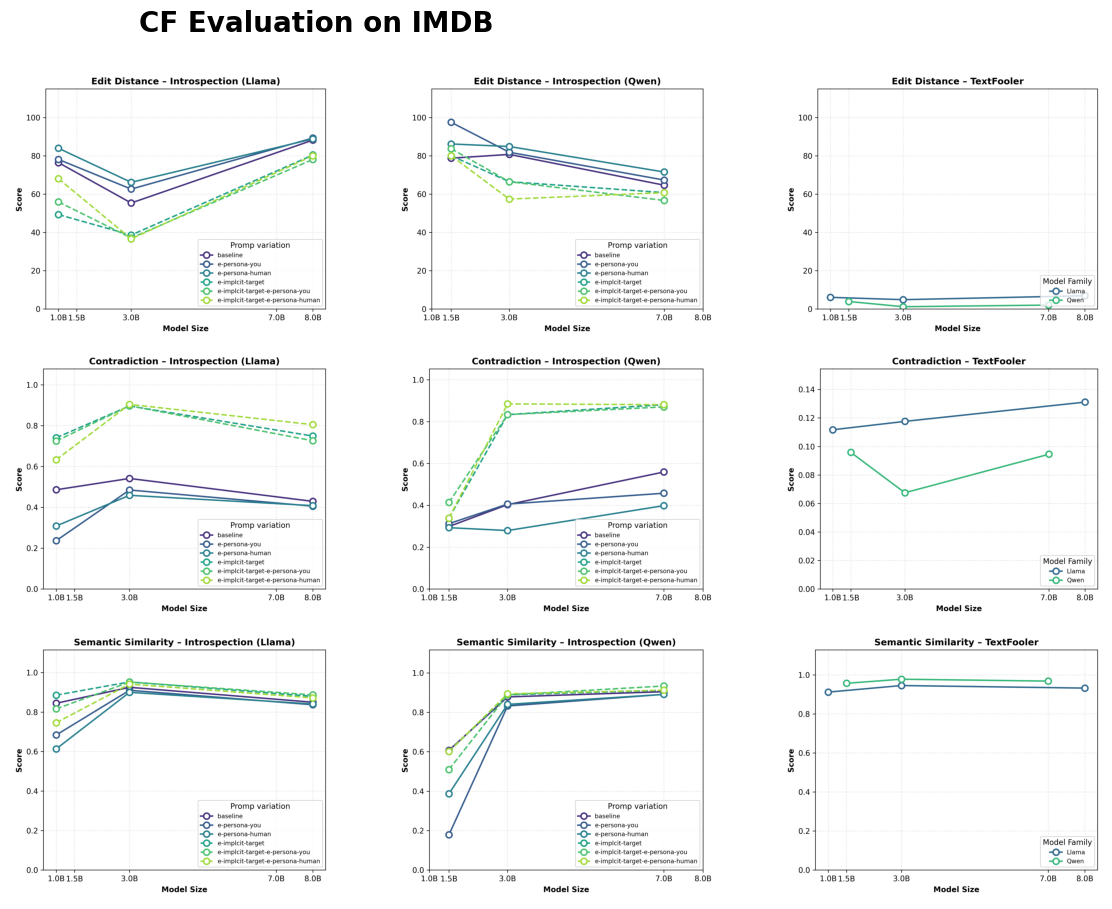

In [55]:
metrics = ['edit_distance', 'contradiction', 'semantic_similarity']
model_families = ['llama', 'qwen']
plotsDir = path + '/results/movie_results/plots/'

num_plots = 3
fig, axes = plt.subplots(len(metrics), num_plots, figsize=(4*num_plots, 3*len(metrics)))
fig.suptitle("CF Evaluation on IMDB", fontsize=20, fontweight='bold', y=1.005, x=0.3)

for row_idx, metric in enumerate(metrics):
    for col_idx, model_family in enumerate(model_families):
        plot_path = plotsDir + f"{metric}_Introspection_{model_family}.png"
        img = mpimg.imread(plot_path)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')

    plot_path = plotsDir + f"{metric}_TextFooler.png"
    img = mpimg.imread(plot_path)
    axes[row_idx, -1].imshow(img)
    axes[row_idx, -1].axis('off')

plt.tight_layout()
plt.show()


###**Task: e-SNLI**

**Experiment:**

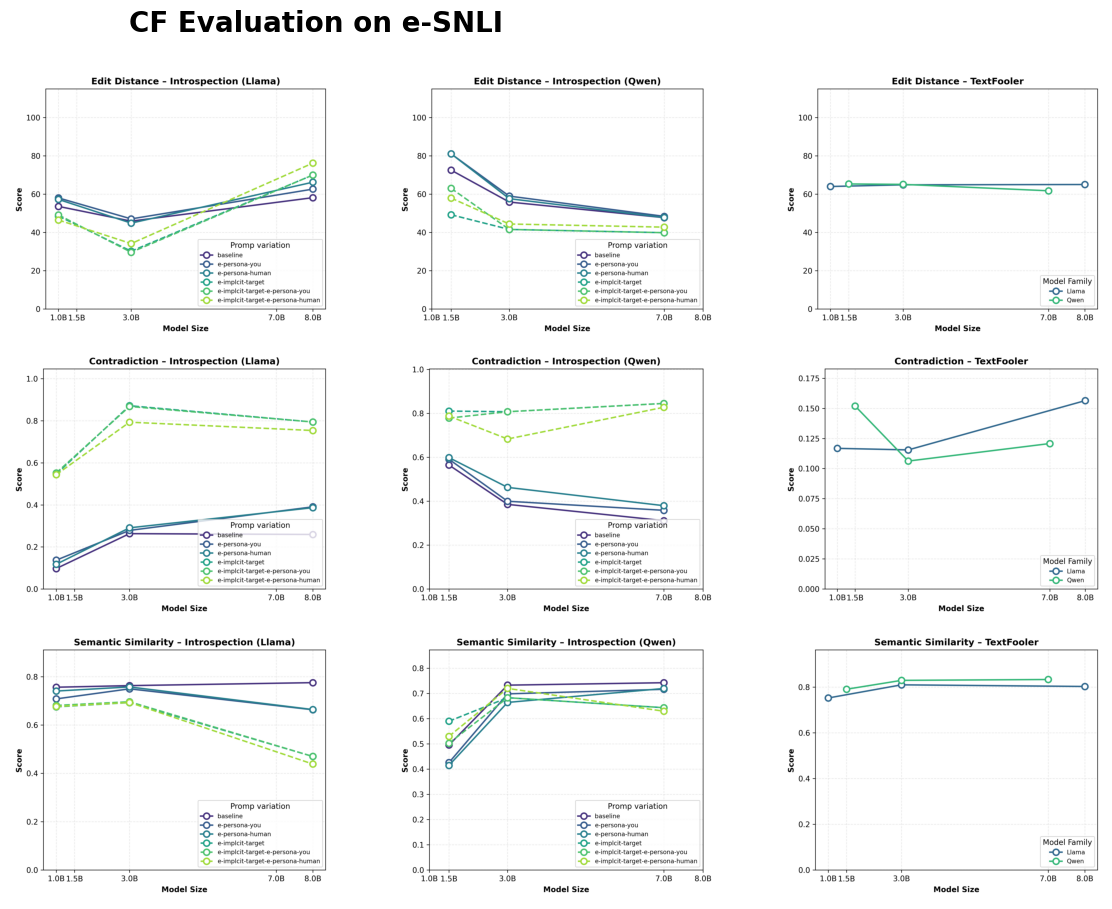

In [54]:
metrics = ['edit_distance', 'contradiction', 'semantic_similarity']
model_families = ['llama', 'qwen']
plotsDir = path + '/results/esnli_results/plots/'

num_plots = 3
fig, axes = plt.subplots(len(metrics), num_plots, figsize=(4*num_plots, 3*len(metrics)))
fig.suptitle("CF Evaluation on e-SNLI", fontsize=20, fontweight='bold', y=1.005, x=0.3)

for row_idx, metric in enumerate(metrics):
    for col_idx, model_family in enumerate(model_families):
        plot_path = plotsDir + f"{metric}_Introspection_{model_family}.png"
        img = mpimg.imread(plot_path)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')

    plot_path = plotsDir + f"{metric}_TextFooler.png"
    img = mpimg.imread(plot_path)
    axes[row_idx, -1].imshow(img)
    axes[row_idx, -1].axis('off')

plt.tight_layout()
plt.show()

#**Counterfactual Edits Against Human-Annotated Feature Importance**

- **True Positive (TP)** — a token that was **deleted, replaced, or inserted** *and* lies **inside** a human-annotated evidence span.  
- **False Positive (FP)** — a token that was **deleted, replaced, or inserted** but lies **outside** any human-annotated evidence span.  
- **False Negative (FN)** — a token that lies **inside** a human-annotated evidence span but was **not** deleted, replaced, or inserted.



**Precision**: What percent of the perturbations in the input are *evidence* supported?

 $$
\text{Precision} = \frac{T_P}{T_P + F_P}
$$

**Recall**: What percent of the *human evidence spans* are covered by the perturbations in the input?  

$$
\text{Recall} = \frac{T_P}{T_P + F_N}
$$


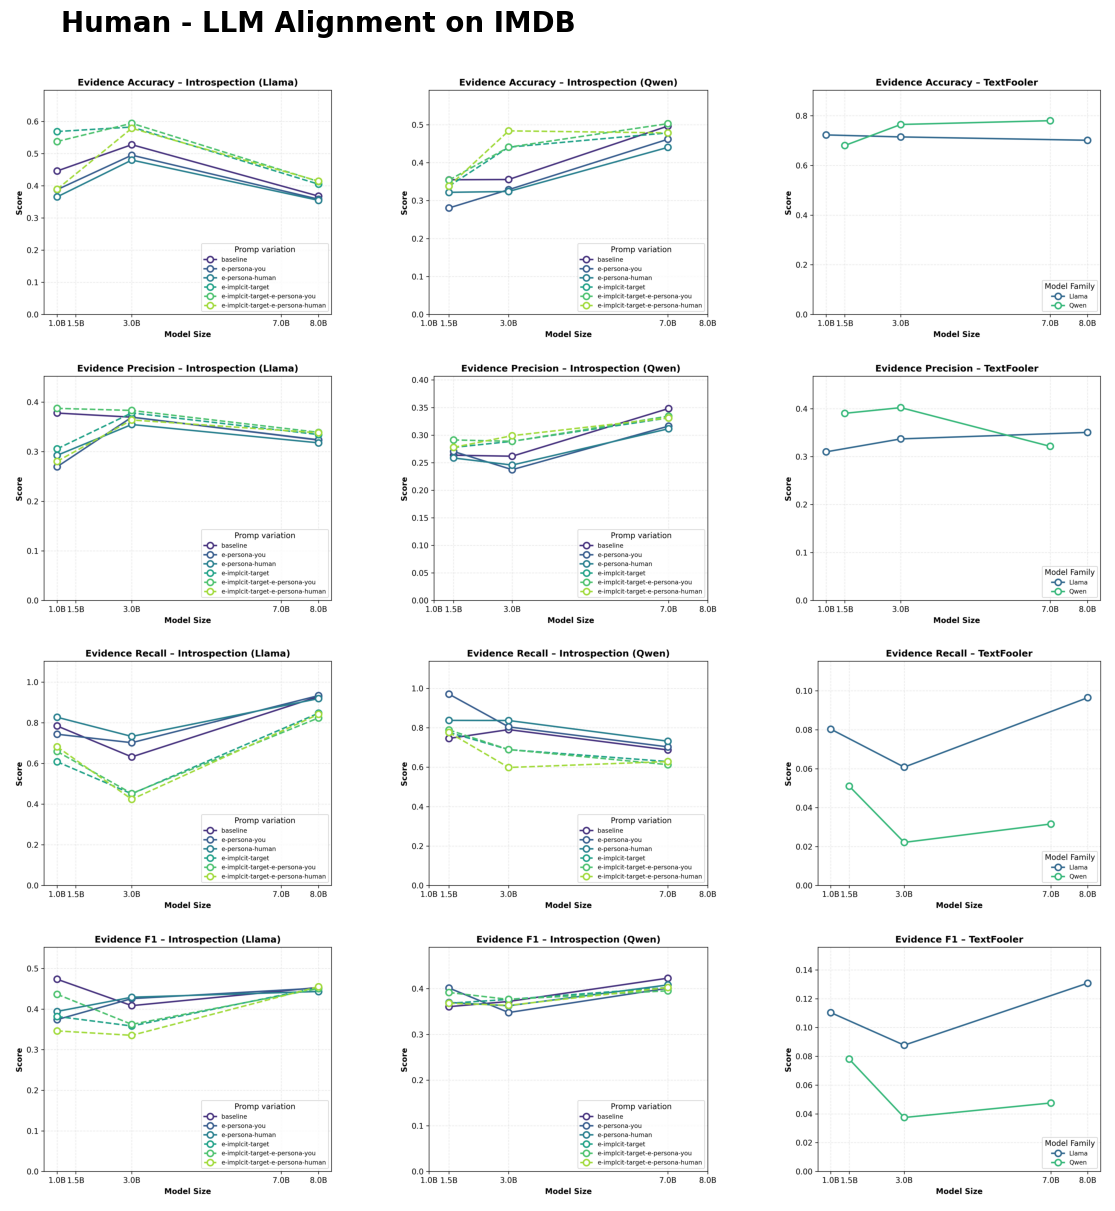

In [52]:
metrics = ['evidence_accuracy', 'evidence_precision', 'evidence_recall', 'evidence_f1']
model_families = ['llama', 'qwen']
plotsDir = path + '/results/movie_results/plots/'

num_plots = 3
fig, axes = plt.subplots(len(metrics), num_plots, figsize=(4*num_plots, 3*len(metrics)))
fig.suptitle("Human - LLM Alignment on IMDB", fontsize=20, fontweight='bold', y=1.005, x=0.3)

for row_idx, metric in enumerate(metrics):
    for col_idx, model_family in enumerate(model_families):
        plot_path = plotsDir + f"{metric}_Introspection_{model_family}.png"
        img = mpimg.imread(plot_path)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')

    plot_path = plotsDir + f"{metric}_TextFooler.png"
    img = mpimg.imread(plot_path)
    axes[row_idx, -1].imshow(img)
    axes[row_idx, -1].axis('off')

plt.tight_layout()
plt.show()

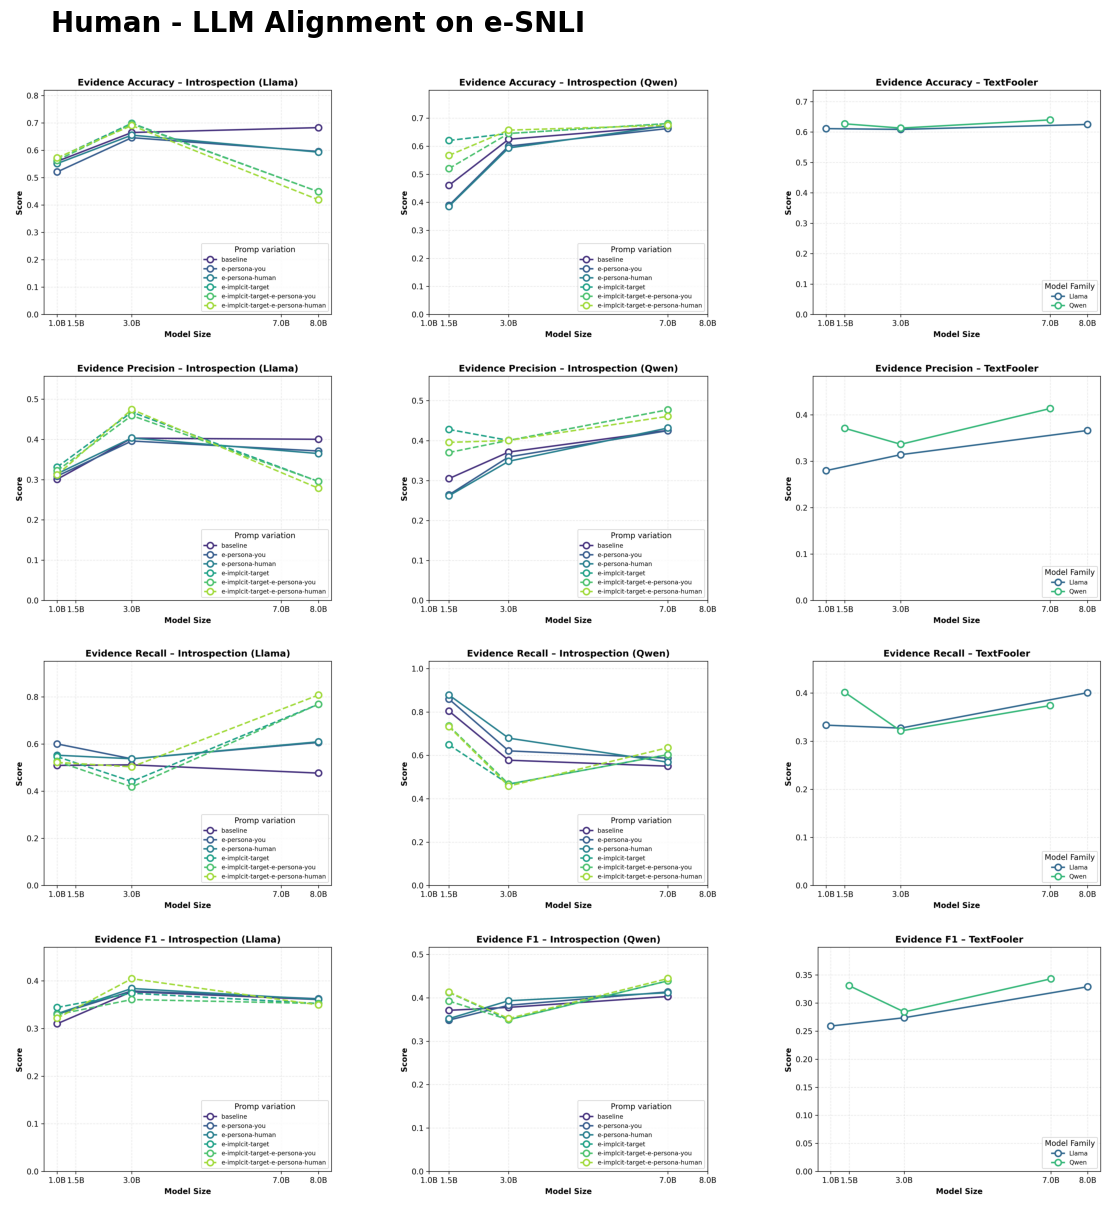

In [53]:
metrics = ['evidence_accuracy', 'evidence_precision', 'evidence_recall', 'evidence_f1']
model_families = ['llama', 'qwen']
plotsDir = path + '/results/esnli_results/plots/'

num_plots = 3
fig, axes = plt.subplots(len(metrics), num_plots, figsize=(4*num_plots, 3*len(metrics)))
fig.suptitle("Human - LLM Alignment on e-SNLI", fontsize=20, fontweight='bold', y=1.005, x=0.3)

for row_idx, metric in enumerate(metrics):
    for col_idx, model_family in enumerate(model_families):
        plot_path = plotsDir + f"{metric}_Introspection_{model_family}.png"
        img = mpimg.imread(plot_path)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')

    plot_path = plotsDir + f"{metric}_TextFooler.png"
    img = mpimg.imread(plot_path)
    axes[row_idx, -1].imshow(img)
    axes[row_idx, -1].axis('off')

plt.tight_layout()
plt.show()